# Experiment #6: Working on Optimizers

**Data preprocessing – Outliers – Loss functions – Optimizers**

### Aim

To develop a regression model for house price prediction, preprocess the
data, detect and treat outliers, implement MAE, MSE and Huber loss functions,
and compare SGD, Momentum, Adagrad, RMSprop, Adam and Adadelta optimizers.

The Kaggle House Prices dataset is used for this experiment. The target
variable is SalePrice. For consistency with the laboratory manual,
SalePrice is converted into lakh units.

## Learning Outcomes

After completing this experiment, we will be able to:

1. Prepare numerical data without data leakage.
2. Handle missing values using training-set statistics.
3. Detect outliers using the Interquartile Range (IQR) method.
4. Compare outlier retention, removal and capping.
5. Explain MAE, MSE and Huber loss.
6. Implement six optimizers using NumPy.
7. Compare different loss functions and optimizers.
8. Select the final model using validation RMSE.
9. Evaluate the selected model once on the test set.

# Part 1: Data inspection and preprocessing

## Step 1: Load and inspect the data

The dataset used is the Kaggle House Prices dataset. It contains information
about residential properties and their corresponding sale prices.

The original target is `SalePrice`. Since the laboratory manual uses
`Price_lakh`, SalePrice is divided by 100000 so that the target is expressed
in lakh units.

For the optimizer experiment, five numerical features are selected:

- OverallQual
- GrLivArea
- GarageCars
- TotalBsmtSF
- YearBuilt

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)



In [43]:
# Load dataset
df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe().T)

Dataset shape: (1460, 81)

First five rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 1

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Feature selection

The original laboratory manual contains five numerical input features.
Since the supplied Kaggle dataset has different column names, equivalent
numerical housing features are selected from the actual dataset.

The selected features are:

| Feature | Description |
|---|---|
| OverallQual | Overall material and finish quality |
| GrLivArea | Above-ground living area |
| GarageCars | Garage capacity in cars |
| TotalBsmtSF | Total basement area |
| YearBuilt | Original construction year |

The target variable is `SalePrice`.

In [44]:
# Select the five numerical features used for the experiment
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt"
]

# Target in lakh units
target = "SalePrice"

X = df[features].copy()
y = df[target].copy() / 100000

print("Selected features:")
print(features)

print("\nTarget: SalePrice converted to lakh units")

display(X.head())

display(y.head())

Selected features:
['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']

Target: SalePrice converted to lakh units


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt
0,7,1710,2,856,2003
1,6,1262,2,1262,1976
2,7,1786,2,920,2001
3,7,1717,3,756,1915
4,8,2198,3,1145,2000


0    2.085
1    1.815
2    2.235
3    1.400
4    2.500
Name: SalePrice, dtype: float64

## Inspection questions

**How many rows and columns are present?**

The complete dataset contains 1460 rows and 81 columns.

**Which columns contain missing values?**

The original dataset contains missing values in several columns. Among the
five selected features, missing values may occur in `GarageCars` and
`TotalBsmtSF`.

**How many duplicate rows are present?**

This is checked using `df.duplicated().sum()`.

**Which variables show unusually large maximum values?**

Among the selected variables, `GrLivArea` and `TotalBsmtSF` can contain
large values and are therefore checked for possible outliers.

## Step 2: Remove duplicates and create train, validation and test sets

The data is divided into:

- 70% training data
- 15% validation data
- 15% testing data

The validation set is used for model selection, while the test set is kept
unseen until the final model has been selected.

In [45]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Recreate X and y after removing duplicates
X = df[features].copy()
y = df[target].copy() / 100000

# 70% training, 15% validation, 15% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)



## Step 3: Impute missing values using training medians

Missing numerical values are replaced using the median calculated only from
the training set.

The same training medians are then applied to validation and test sets.

This prevents data leakage because information from validation and test data
is not used while learning the preprocessing parameters.

In [46]:
# Calculate medians only from training data
train_medians = X_train.median()

# Apply training medians to all three datasets
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Remaining missing values in training set:",
      X_train.isna().sum().sum())

print("Remaining missing values in validation set:",
      X_val.isna().sum().sum())

print("Remaining missing values in test set:",
      X_test.isna().sum().sum())

Remaining missing values in training set: 0
Remaining missing values in validation set: 0
Remaining missing values in test set: 0


## Checkpoint 1

| Check | Result |
|---|---|
| Duplicates removed | Checked using `duplicated()` |
| Training rows | Printed above |
| Validation rows | Printed above |
| Test rows | Printed above |
| Missing values after imputation | Should be 0 |

### Why training medians?

Using the complete dataset to calculate replacement values would allow
information from validation and test data to influence the training process.
This is called **data leakage**.

Therefore, preprocessing parameters are learned only from the training set.

# Part 2: Outlier detection and treatment

The Interquartile Range (IQR) method is used to identify potential outliers.

For a variable x:

IQR = Q3 - Q1

Lower limit = Q1 - 1.5 × IQR

Upper limit = Q3 + 1.5 × IQR

Values below the lower limit or above the upper limit are flagged as
potential outliers.

The limits are calculated using the training data only.

In [47]:
def iqr_limits(frame, columns):
    limits = {}

    for col in columns:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1

        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr

        limits[col] = (low, high)

    return limits


# Feature outlier limits
feature_limits = iqr_limits(X_train, X_train.columns)

# Target outlier limits
target_limits = iqr_limits(
    pd.DataFrame({"SalePrice": y_train}),
    ["SalePrice"]
)

print("IQR limits and outlier counts:\n")

for col, (low, high) in feature_limits.items():

    count = (
        (X_train[col] < low) |
        (X_train[col] > high)
    ).sum()

    print(
        col,
        "-> Lower:", round(low, 2),
        "Upper:", round(high, 2),
        "Outliers:", count
    )

IQR limits and outlier counts:

OverallQual -> Lower: 2.0 Upper: 10.0 Outliers: 2
GrLivArea -> Lower: 164.88 Upper: 2771.88 Outliers: 21
GarageCars -> Lower: -0.5 Upper: 3.5 Outliers: 1
TotalBsmtSF -> Lower: 46.5 Upper: 2042.5 Outliers: 43
YearBuilt -> Lower: 1881.0 Upper: 2073.0 Outliers: 4


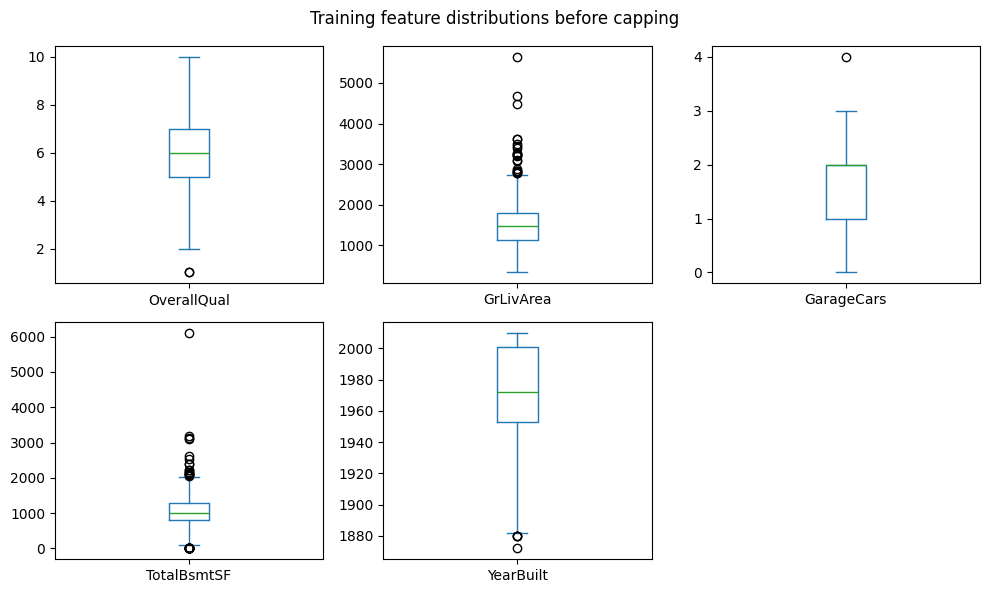

In [48]:
X_train.plot(
    kind="box",
    subplots=True,
    layout=(2, 3),
    figsize=(10, 6),
    sharex=False,
    sharey=False
)

plt.suptitle("Training feature distributions before capping")
plt.tight_layout()
plt.show()

## Step 5: Compare three outlier treatment strategies

Three strategies are considered:

**Strategy A – Retain**

All observations are retained without removing outliers.

**Strategy B – Remove**

Training observations having target outliers are removed.

**Strategy C – Cap**

Feature values outside their training IQR limits are replaced by the
corresponding lower or upper limit.

For the remaining experiment, Strategy C is used.

The target variable is not capped so that the loss functions can demonstrate
their different responses to large residuals.

In [49]:
# Strategy A: retain all observations
X_train_keep = X_train.copy()
y_train_keep = y_train.copy()

# Strategy B: remove target outliers from training data only
low_y, high_y = target_limits["SalePrice"]

mask = y_train.between(low_y, high_y)

X_train_remove = X_train.loc[mask].copy()
y_train_remove = y_train.loc[mask].copy()

# Strategy C: cap feature values using training IQR limits
X_train_cap = X_train.copy()
X_val_cap = X_val.copy()
X_test_cap = X_test.copy()

for col, (low, high) in feature_limits.items():

    X_train_cap[col] = X_train_cap[col].clip(low, high)
    X_val_cap[col] = X_val_cap[col].clip(low, high)
    X_test_cap[col] = X_test_cap[col].clip(low, high)

print("Rows retained:", len(X_train_keep))
print("Rows after target-outlier removal:", len(X_train_remove))

Rows retained: 1022
Rows after target-outlier removal: 981


## Step 6: Standardize features using the capped training set

The capped features are standardized using `StandardScaler`.

The scaler is fitted only on the training data.

The same learned scaling parameters are then applied to validation and test
data.

In [50]:
scaler = StandardScaler()

Xtr = scaler.fit_transform(X_train_cap)
Xva = scaler.transform(X_val_cap)
Xte = scaler.transform(X_test_cap)

ytr = y_train.to_numpy()
yva = y_val.to_numpy()
yte = y_test.to_numpy()

print("Training data shape:", Xtr.shape)
print("Validation data shape:", Xva.shape)
print("Test data shape:", Xte.shape)

Training data shape: (1022, 5)
Validation data shape: (219, 5)
Test data shape: (219, 5)


## Decision questions

### Why should validation and test outliers not be removed automatically?

Validation and test data represent unseen real-world observations. Removing
their outliers after looking at them can change the evaluation distribution
and introduce bias into the final evaluation.

### Which treatment preserves the number of observations?

**Capping** preserves the number of observations because no rows are removed.

### What risk arises when valid extreme houses are removed?

A genuinely expensive or unusually large house may be a valid observation.
Removing it can discard useful information and make the model less
representative of real-world house prices.

# Part 3: Loss functions

Three loss functions are used:

| Loss | Formula | Behaviour |
|---|---|---|
| MAE | mean of |e| | Linear penalty and more resistant to outliers |
| MSE | mean of e² | Quadratic penalty; large errors receive much more weight |
| Huber | 0.5e² if |e| ≤ delta, otherwise delta(|e| - 0.5delta) | Quadratic for small errors and linear for large errors |

Here:

e = prediction - actual

In [51]:
def loss_and_grad(y, pred, loss_name="mse", delta=10.0):

    # Residual
    r = pred - y
    n = len(y)

    # MSE
    if loss_name == "mse":
        return np.mean(r ** 2), 2 * r / n

    # MAE
    if loss_name == "mae":
        return np.mean(np.abs(r)), np.sign(r) / n

    # Huber
    if loss_name == "huber":

        a = np.abs(r)

        terms = np.where(
            a <= delta,
            0.5 * r ** 2,
            delta * (a - 0.5 * delta)
        )

        grad = np.where(
            a <= delta,
            r,
            delta * np.sign(r)
        ) / n

        return np.mean(terms), grad

    raise ValueError("Choose mse, mae or huber")

## Manual verification

For:

Actual values = [10, 20, 30]

Predicted values = [12, 19, 35]

Residuals using prediction - actual:

[2, -1, 5]

For Huber loss, delta = 2.

Expected values:

- MAE = 2.67
- MSE = 10.00
- Huber loss = 3.50

In [52]:
actual = np.array([10, 20, 30])
predicted = np.array([12, 19, 35])

mae_value, _ = loss_and_grad(
    actual, predicted, "mae"
)

mse_value, _ = loss_and_grad(
    actual, predicted, "mse"
)

huber_value, _ = loss_and_grad(
    actual, predicted, "huber", delta=2
)

print("MAE:", round(mae_value, 2))
print("MSE:", round(mse_value, 2))
print("Huber loss:", round(huber_value, 2))

MAE: 2.67
MSE: 10.0
Huber loss: 3.5


# Part 4: Optimizers implemented in NumPy

The regression model is:

prediction = Xw + b

where:

- X = input features
- w = model weights
- b = bias/intercept

Each optimizer receives the same gradient but updates the parameters in a
different way.

The six optimizers implemented are:

1. SGD
2. Momentum
3. Adagrad
4. RMSprop
5. Adam
6. Adadelta

In [53]:
def add_bias(X):
    return np.c_[X, np.ones(len(X))]


def train_model(
    X,
    y,
    Xv,
    yv,
    loss_name,
    optimizer,
    lr=0.01,
    epochs=500,
    delta=10.0,
    seed=42
):

    Xb = add_bias(X)
    Xvb = add_bias(Xv)

    rng = np.random.default_rng(seed)

    # Initial parameters
    theta = rng.normal(0, 0.01, Xb.shape[1])

    # Optimizer variables
    velocity = np.zeros_like(theta)
    cache = np.zeros_like(theta)

    m = np.zeros_like(theta)
    v = np.zeros_like(theta)

    rho = 0.9
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8

    delta_acc = np.zeros_like(theta)

    history = []

    for epoch in range(1, epochs + 1):

        # Forward pass
        pred = Xb @ theta

        # Loss and derivative
        train_loss, d_pred = loss_and_grad(
            y,
            pred,
            loss_name,
            delta
        )

        # Gradient
        grad = Xb.T @ d_pred

        # SGD
        if optimizer == "sgd":

            update = lr * grad

        # Momentum
        elif optimizer == "momentum":

            velocity = 0.9 * velocity + grad
            update = lr * velocity

        # Adagrad
        elif optimizer == "adagrad":

            cache += grad ** 2

            update = (
                lr * grad /
                (np.sqrt(cache) + eps)
            )

        # RMSprop
        elif optimizer == "rmsprop":

            cache = (
                rho * cache +
                (1 - rho) * grad ** 2
            )

            update = (
                lr * grad /
                (np.sqrt(cache) + eps)
            )

        # Adam
        elif optimizer == "adam":

            m = beta1 * m + (1 - beta1) * grad

            v = beta2 * v + (1 - beta2) * grad ** 2

            mhat = m / (1 - beta1 ** epoch)
            vhat = v / (1 - beta2 ** epoch)

            update = (
                lr * mhat /
                (np.sqrt(vhat) + eps)
            )

        # Adadelta
        elif optimizer == "adadelta":

            cache = (
                rho * cache +
                (1 - rho) * grad ** 2
            )

            update = (
                np.sqrt(delta_acc + eps) /
                np.sqrt(cache + eps)
            ) * grad

            delta_acc = (
                rho * delta_acc +
                (1 - rho) * update ** 2
            )

        else:

            raise ValueError("Unknown optimizer")

        # Parameter update
        theta -= update

        # Validation loss
        val_pred = Xvb @ theta

        val_loss, _ = loss_and_grad(
            yv,
            val_pred,
            loss_name,
            delta
        )

        history.append(
            (train_loss, val_loss)
        )

    return theta, np.array(history)

## Optimizer concepts

| Optimizer | Main idea | Useful observation |
|---|---|---|
| SGD | Uses one learning rate for all parameters | Simple baseline but sensitive to learning rate |
| Momentum | Accumulates velocity from previous gradients | Reduces oscillations and can accelerate learning |
| Adagrad | Uses accumulated squared gradients | Learning rate can become very small over time |
| RMSprop | Uses moving average of squared gradients | Prevents Adagrad's denominator from growing indefinitely |
| Adam | Combines momentum and adaptive squared gradients | Adapts learning to individual parameters |
| Adadelta | Uses moving averages for gradients and updates | Reduces dependence on a manually chosen global rate |

# Part 5: Controlled comparison

A single learning rate may not work equally well for all optimizers.

Therefore, the following learning rates are tested:

[0.001, 0.005, 0.01, 0.05]

For Adadelta, the learning rate is fixed at 1.0 as specified in the
laboratory manual.

For every loss-optimizer combination, the configuration having the lowest
validation RMSE is selected.

The test set is not used during this selection process.

In [54]:
losses = ["mae", "mse", "huber"]

optimizers = [
    "sgd",
    "momentum",
    "adagrad",
    "rmsprop",
    "adam",
    "adadelta"
]

learning_rates = [
    0.001,
    0.005,
    0.01,
    0.05
]

results = []

for loss_name in losses:

    for opt in optimizers:

        best = None

        # Adadelta uses 1.0
        rates = [1.0] if opt == "adadelta" else learning_rates

        for lr in rates:

            theta, history = train_model(
                Xtr,
                ytr,
                Xva,
                yva,
                loss_name,
                opt,
                lr=lr,
                epochs=500,
                delta=10.0,
                seed=42
            )

            pred = add_bias(Xva) @ theta

            record = {
                "loss": loss_name,
                "optimizer": opt,
                "lr": lr,

                "val_MAE":
                    mean_absolute_error(yva, pred),

                "val_RMSE":
                    np.sqrt(
                        mean_squared_error(yva, pred)
                    ),

                "val_R2":
                    r2_score(yva, pred),

                "theta": theta,
                "history": history
            }

            if (
                best is None or
                record["val_RMSE"] < best["val_RMSE"]
            ):
                best = record

        results.append(best)


summary = pd.DataFrame([
    {
        k: v
        for k, v in r.items()
        if k not in ["theta", "history"]
    }
    for r in results
])

print("Validation results:")
display(
    summary
    .sort_values("val_RMSE")
    .round(3)
)

Validation results:


,loss,optimizer,lr,val_MAE,val_RMSE,val_R2
9,mse,rmsprop,0.010,0.223,0.299,0.857
15,huber,rmsprop,0.010,0.223,0.299,0.857
12,huber,sgd,0.050,0.221,0.300,0.857
13,huber,momentum,0.005,0.221,0.300,0.857
6,mse,sgd,0.050,0.221,0.300,0.857
7,mse,momentum,0.050,0.221,0.300,0.857
16,huber,adam,0.050,0.221,0.300,0.857
10,mse,adam,0.050,0.221,0.300,0.857
3,mae,rmsprop,0.050,0.231,0.314,0.843
1,mae,momentum,0.001,0.224,0.331,0.825


In [55]:
# Complete results table in the same format as the manual

results_table = summary[
    [
        "loss",
        "optimizer",
        "lr",
        "val_MAE",
        "val_RMSE",
        "val_R2"
    ]
].copy()

results_table.columns = [
    "Loss",
    "Optimizer",
    "Best rate",
    "Val MAE",
    "Val RMSE",
    "Val R squared"
]

display(
    results_table
    .sort_values("Val RMSE")
    .round(3)
)

,Loss,Optimizer,Best rate,Val MAE,Val RMSE,Val R squared
9,mse,rmsprop,0.010,0.223,0.299,0.857
15,huber,rmsprop,0.010,0.223,0.299,0.857
12,huber,sgd,0.050,0.221,0.300,0.857
13,huber,momentum,0.005,0.221,0.300,0.857
6,mse,sgd,0.050,0.221,0.300,0.857
7,mse,momentum,0.050,0.221,0.300,0.857
16,huber,adam,0.050,0.221,0.300,0.857
10,mse,adam,0.050,0.221,0.300,0.857
3,mae,rmsprop,0.050,0.231,0.314,0.843
1,mae,momentum,0.001,0.224,0.331,0.825


## Step 10: Plot representative learning curves

The validation loss curves for the six optimizers are plotted using Huber
loss.

A faster-converging optimizer generally reaches a low validation loss in
fewer epochs.

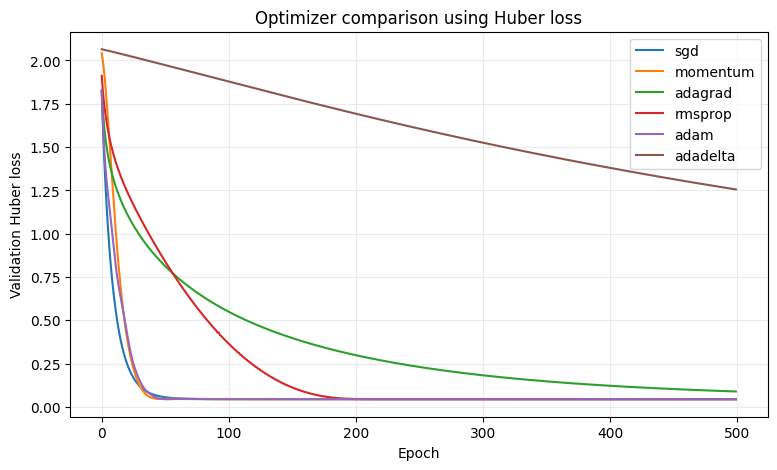

In [56]:
plt.figure(figsize=(9, 5))

for r in results:

    if r["loss"] == "huber":

        plt.plot(
            r["history"][:, 1],
            label=r["optimizer"]
        )

plt.xlabel("Epoch")
plt.ylabel("Validation Huber loss")
plt.title("Optimizer comparison using Huber loss")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# Part 6: Final model and test evaluation

The final model is selected using the lowest validation RMSE.

Only after the model has been selected is the test set used.

This prevents test-set information from influencing model selection.

In [57]:
# Select model using validation RMSE
best = min(
    results,
    key=lambda r: r["val_RMSE"]
)

# Test prediction
test_pred = add_bias(Xte) @ best["theta"]

print("Selected loss:", best["loss"])
print("Selected optimizer:", best["optimizer"])
print("Learning rate:", best["lr"])

print("\nTest MAE:",
      mean_absolute_error(yte, test_pred))

print("Test RMSE:",
      np.sqrt(mean_squared_error(yte, test_pred)))

print("Test R squared:",
      r2_score(yte, test_pred))

Selected loss: mse
Selected optimizer: rmsprop
Learning rate: 0.01

Test MAE: 0.27334045745996055
Test RMSE: 0.44273951245488713
Test R squared: 0.7424308996457052


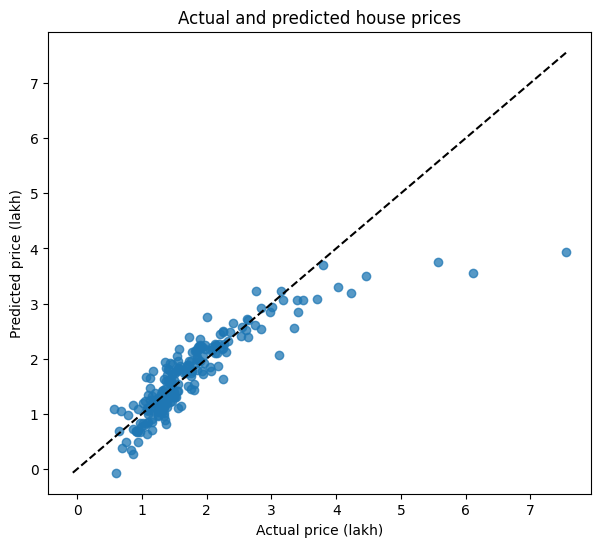

In [58]:
plt.figure(figsize=(7, 6))

plt.scatter(
    yte,
    test_pred,
    alpha=0.75
)

limits = [
    min(yte.min(), test_pred.min()),
    max(yte.max(), test_pred.max())
]

plt.plot(
    limits,
    limits,
    "k--"
)

plt.xlabel("Actual price (lakh)")
plt.ylabel("Predicted price (lakh)")
plt.title("Actual and predicted house prices")

plt.show()

## Final results

| Final item | Value |
|---|---|
| Selected loss function | Obtained from final model |
| Selected optimizer | Obtained from final model |
| Learning rate | Obtained from final model |
| Test MAE | Obtained from final model |
| Test RMSE | Obtained from final model |
| Test R squared | Obtained from final model |

The exact values are automatically generated when the notebook is executed.

In [59]:
final_results = pd.DataFrame({
    "Final item": [
        "Selected loss function",
        "Selected optimizer",
        "Learning rate",
        "Test MAE",
        "Test RMSE",
        "Test R squared"
    ],
    "Value": [
        best["loss"],
        best["optimizer"],
        best["lr"],
        mean_absolute_error(yte, test_pred),
        np.sqrt(mean_squared_error(yte, test_pred)),
        r2_score(yte, test_pred)
    ]
})

display(final_results)

,Final item,Value
0,Selected loss function,mse
1,Selected optimizer,rmsprop
2,Learning rate,0.01
3,Test MAE,0.27334
4,Test RMSE,0.44274
5,Test R squared,0.742431


## Interpretation Questions

### 1. Which observations were flagged as outliers? Explain whether they could be valid extreme cases or data errors.

The IQR method flagged observations that were below the lower IQR limit or
above the upper IQR limit. In house-price data, extreme values such as very
large living areas or unusually large basements may represent genuine
properties rather than data-entry errors. Therefore, they should not be
automatically deleted.

### 2. How did capping change the feature distributions and validation performance?

Capping limited extreme feature values to the lower and upper IQR limits.
This reduced the influence of extreme observations while preserving all
training observations. The effect on validation performance can be observed
from the validation RMSE and MAE produced by the experiment.

### 2. How did capping change the feature distributions and validation performance?

Capping limited extreme feature values to the lower and upper IQR limits.
This reduced the influence of extreme observations while preserving all
training observations. The effect on validation performance can be observed
from the validation RMSE and MAE produced by the experiment.

In [60]:
best_by_rmse = summary.loc[
    summary["val_RMSE"].idxmin()
]

best_by_mae = summary.loc[
    summary["val_MAE"].idxmin()
]

print("Lowest validation RMSE:")
print(best_by_rmse)

print("\nLowest validation MAE:")
print(best_by_mae)

Lowest validation RMSE:
loss              mse
optimizer     rmsprop
lr               0.01
val_MAE      0.223349
val_RMSE     0.299474
val_R2       0.857213
Name: 9, dtype: object

Lowest validation MAE:
loss            huber
optimizer    momentum
lr              0.005
val_MAE      0.221058
val_RMSE     0.300149
val_R2       0.856569
Name: 13, dtype: object


### 4. Which optimizer converged fastest? Support the answer using the learning curves.

The optimizer that reaches a low validation loss in fewer epochs can be
considered faster converging for this experiment. The Huber validation
learning-curve graph is used as evidence.

### 5. Why can MSE be strongly affected by unusually expensive houses?

MSE squares the residual. Therefore, a very large prediction error caused by
an unusually expensive house receives a disproportionately large penalty.

For example, an error of 2 has a squared value of 4, while an error of 10
has a squared value of 100. Hence, large residuals have much greater
influence under MSE.

### 6. What role does delta play in Huber loss? Predict what happens when delta decreases.

Delta controls the point at which Huber loss changes from quadratic behaviour
to linear behaviour.

For residuals smaller than delta, Huber behaves like squared error. For
larger residuals, it behaves approximately like absolute error.

If delta decreases, more residuals fall into the linear region, making Huber
more resistant to large errors and outliers.

### 6. What role does delta play in Huber loss? Predict what happens when delta decreases.

Delta controls the point at which Huber loss changes from quadratic behaviour
to linear behaviour.

For residuals smaller than delta, Huber behaves like squared error. For
larger residuals, it behaves approximately like absolute error.

If delta decreases, more residuals fall into the linear region, making Huber
more resistant to large errors and outliers.

### 7. Why was the test set used only after model selection?

The test set is intended to provide an unbiased estimate of how the final
selected model performs on unseen data.

If the test set were repeatedly used while selecting the loss function,
optimizer or learning rate, information from the test set could influence
the model selection process. Therefore, validation data is used for
selection and the test set is used only once at the end.

### 8. State one limitation of this experiment and one improvement you would make.

**Limitation:**

Only five numerical features were used from the complete house-price
dataset, so some useful information contained in the categorical and other
numerical variables was not included.

**Improvement:**

Categorical variables could be encoded and more relevant numerical features
could be included. The experiment could then be repeated using the expanded
feature set and cross-validation for more reliable model comparison.# Submission checklist

- [ ] Completed manual tables
- [ ] Notebook with executable code and outputs
- [ ] Missing-value and outlier evidence
- [ ] Validation comparison and learning-curve graph
- [ ] Final actual-versus-predicted graph
- [ ] Written answers and final conclusion

# Submission checklist

- [ ] Completed manual tables
- [ ] Notebook with executable code and outputs
- [ ] Missing-value and outlier evidence
- [ ] Validation comparison and learning-curve graph
- [ ] Final actual-versus-predicted graph
- [ ] Written answers and final conclusion# Conclusion

In this experiment, a linear regression model was developed using the Kaggle
House Prices dataset. The data was cleaned by removing duplicate records,
splitting the data into training, validation and test sets, and imputing
missing values using training-set medians.

Potential outliers were identified using the IQR method. Feature capping was
used as the final outlier treatment so that extreme feature values had
limited influence while all observations were retained.

MAE, MSE and Huber loss functions were implemented manually using NumPy.
Six optimizers — SGD, Momentum, Adagrad, RMSprop, Adam and Adadelta — were
then compared using validation MAE, RMSE and R squared.

The final configuration was selected using validation RMSE, and the selected
model was evaluated once on the unseen test set.